---
title: Transmission Dither Locking, Pound-Drever-Hall Michelson, and Fabry-Perot Michelson  - Homework 04
date: 2025-04-06
authors:
  - name: Professor Craig Cahillane
    orcid: 0000-0002-3888-314X
    affiliations:
      - Syracuse University
numbering:
  heading_1: true
  heading_2: true
  heading_3: true
---

This is the fourth homework assignment for *Lasers and Optomechanics* at Syracuse University.\
**It is due Monday, April 6th, 2026 by 5 pm**

**<span style="color:#ff5555;">You will need to complete the questions in this jupyter notebook and submit it via `gitlab`</span>**


# Transmitted Field Dither Locking

In class, we investigated dither locking using the reflected field $E_\mathrm{refl}$ from a Fabry-Perot cavity.

In this problem, investigate whether it is possible to use $E_\mathrm{trans}$ to hold lock.


## Plot of Fabry-Perot $E_\mathrm{trans}$ versus $E_\mathrm{trans}$

Plot both $E_\mathrm{refl}$ and $E_\mathrm{trans}$ over a span of $\phi \in \left[ -\dfrac{\pi}{2},\dfrac{3\pi}{2} \right]$

Do you notice anything different about the resonance points?


## Total $E_\mathrm{trans}$ with end-mirror moduation 

If we apply an end-mirror modulation $\Delta x \cos(\omega t)$ to our Fabry-Perot cavity, 
what is the total $E_\mathrm{trans}(t)$ field?


## Calculate the total transmitted power $P_\mathrm{trans}(t)$

Calculate $P_\mathrm{trans}(t) = |E_\mathrm{trans}(t)|^2$

You may set $\Delta x^2 = 0$ for simplicity in the calculations.  
You should end up with only DC and 1$\omega$ terms.

You may leave this power term in a general form if you wish, 
but you must be clear what each of the contributing fields are.

## Calculate the transmitted power demodulated at $\omega$ 
Calculate the demodulated term $P_\mathrm{trans}(\omega) = P^I_\mathrm{trans}(\omega) + i P^Q_\mathrm{trans}(\omega)$.
This should be directly proportional to $\Delta x$.

## Plot the length to transmitted power function phase sweep
Plot the real and imaginary parts of $\dfrac{P_\mathrm{trans}(\omega)}{\Delta x}$ over $\phi \in \left[ -\dfrac{\pi}{2},\dfrac{3\pi}{2} \right]$

Choosing some low to moderate finesse cavity parameters, 
plot your derived function $\dfrac{P_\mathrm{trans}}{\Delta x}(\omega)$ as a function of carrier phase $\phi$.

Let the cavity parameters be
$$L = 1~\mathrm{m}\\ P_\mathrm{in} = 1~\mathrm{W}\\ T_1 = 0.3\\ T_2 = 0.3\\ \lambda = 1064~\mathrm{nm}\\ \omega = 2 \pi (100~\mathrm{Hz})$$

## Plot the length to transmitted power transfer function

Plot your transfer function magnitude and phase $\dfrac{P_\mathrm{trans}}{\Delta x}(\omega)$ as a function of frequency $f = \omega / (2\pi)$.

Use the same cavity parameters as above, but allow $f \in [3 \times 10^3, 3 \times 10^8]~\mathrm{Hz}$, while setting $\phi = 1^{\circ}$.

# <span style="color:rgb(255, 0, 200)">Question 1 Answers</a>

## <span style="color:rgb(253, 120, 255)">1.1: Plot of Fabry Perot Etrans and Etrans (?)  

$$ 
E_{\text{refl}}=\frac{r_1 - r_2 e^{-2i\Phi}}{1-r_1 r_2 e^{-i2\Phi}}
$$

$$ 
E_{\text{trans}}=\frac{t_1 t_2 e^{-i\Phi}}{1-r_1 r_2 e^{-i2\Phi}}
$$



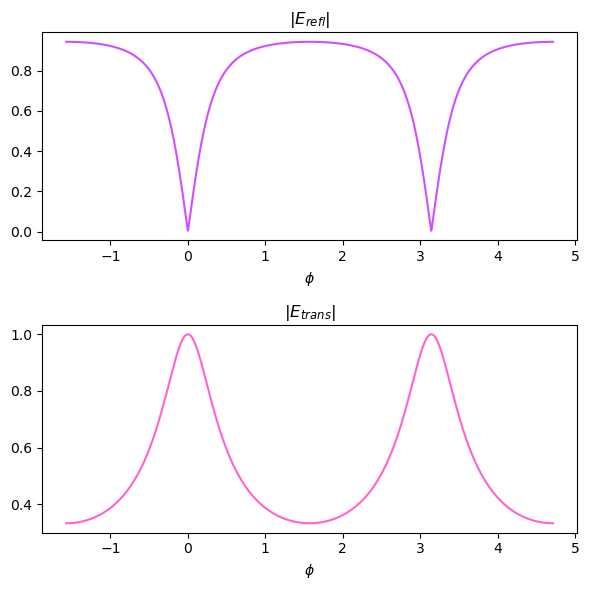

In [44]:
import numpy as np
import matplotlib.pyplot as plt


r1, r2 = np.sqrt(1/2), np.sqrt(1/2)
t1, t2 = np.sqrt(1 - r1**2), np.sqrt(1 - r2**2) 

phi = np.linspace(-np.pi/2, 3*np.pi/2, 1000)

E_refl = (r1 - r2 * np.exp(-2j*phi)) / (1 - r1*r2 * np.exp(-2j*phi))
E_trans = (t1*t2 * np.exp(-1j*phi)) / (1 - r1*r2 * np.exp(-2j*phi))

fig, ax = plt.subplots(2, 1, figsize=(6, 6))


#------------- E refl -------------#
ax[0].plot(phi, np.abs(E_refl), color="#d34eff")
ax[0].set_title(r'$|E_{refl}|$')
ax[0].set_xlabel(r'$\phi$')


#------------- E trans -------------#
ax[1].plot(phi, np.abs(E_trans), color="#ff63d0")
ax[1].set_title(r'$|E_{trans}|$')
ax[1].set_xlabel(r'$\phi$')

plt.tight_layout()
plt.show()

##### <span style="color:rgb(207, 139, 208)">Do you notice anything different about the resonance points? 


 

## <span style="color:rgb(253, 120, 255)">1.2: Total Etrans with end-mirror modulation

After adding modulation $$ \Delta x\cos(\omega t) $$

$$ 
\rightarrow E_{\text{trans tot}}(t) = E_{\text{carrier}} + E_{\text{upper sideband}} + E_{\text{lower sideband}} 
$$

The carrier beam transmits through the first mirror, travels the length of the cavity, then transmits through the end mirror. The beam can also loop through Ecav and Ecav2 n times by being reflected inside the cavity before being transmitted out, so we also need to include the loop suppression. Thus,

$$
E_{\text{carrier}} = E_{in}\frac{t_1t_2e^{-i\phi}}{1-r_1r_2e^{-2i\phi}}
$$

The sidebands are created at the reflection off the end mirror being dithered by the modulation $ \Delta x\cos(\omega t) $. 

To get to the point where the sidebands are created, the input beam transfers through the first mirror, travels the length of the cavity, and is reflected by the second mirror. It can also loop through the cavity, so we also multiply it by the loop suppression to get the following transfer function:

$$
\frac{E_{cav}}{E_{in}}=\frac{-t_1r_2e^{-i\phi}}{1-r_1r_2e^{-2i\phi}}
$$

Once the sidebands are created, to get to E trans they have travel the length of the cavity, are reflected off the first mirror, travel back down the cavity, and are transmitted by the second mirror. They can also loop in the cavity n times, so again we multiply by the loop suppression to get the following transfer function:

$$
\frac{E_{trans}}{E_{cav}}=\frac{-r_1t_2e^{-2i\phi}}{1-r_1r_2e^{-2i\phi}}
$$

We then use these two transfer functions to get $E_{\text{upper sideband}}$ and $E_{\text{lower sideband}}$ by multiplying these and taking the newly created sideband frequencies into account:

$$
E_{\text{lower sideband}} = iE_{in}\times \frac{E_{cav}}{E_{in}}(\omega_0)\times \frac{E_{trans}}{E_{cav}}(\omega_0-\Omega)\times \Gamma e^{i(\omega_0-\Omega) t}
$$

$$
E_{\text{upper sideband}}= iE_{in}\times \frac{E_{cav}}{E_{in}}(\omega_0)\times \frac{E_{trans}}{E_{cav}}(\omega_0+\Omega)\times \Gamma e^{i(\omega_0+\Omega) t}
$$

so now

$$
E_{\text{trans tot}}(t) = E_{in}\frac{t_1t_2e^{-i\phi}}{1-r_1r_2e^{-2i\phi}} + iE_{in}\bigg(\frac{-t_1r_2e^{-i\phi}}{1-r_1r_2e^{-2i\phi}}\bigg)\bigg(\frac{-r_1t_2e^{-2i\phi}}{1-r_1r_2e^{-2i\phi}}\bigg)\Gamma e^{i(\omega_0-\Omega) t}
+ iE_{in}\bigg(\frac{-t_1r_2e^{-i\phi}}{1-r_1r_2e^{-2i\phi}}\bigg)\bigg(\frac{-r_1t_2e^{-2i\phi}}{1-r_1r_2e^{-2i\phi}}\bigg)\Gamma e^{i(\omega_0+\Omega) t}
$$






## <span style="color:rgb(253, 120, 255)">1.3: Calculate total transmitted power Ptrans(t)

## <span style="color:rgb(253, 120, 255)">1.4: Calculate the transmitted power demodulated at omega

## <span style="color:rgb(253, 120, 255)">1.5: Plot the length to transmitted power function phase sweep

## <span style="color:rgb(253, 120, 255)">1.6: Plot the length to transmitted power transfer function

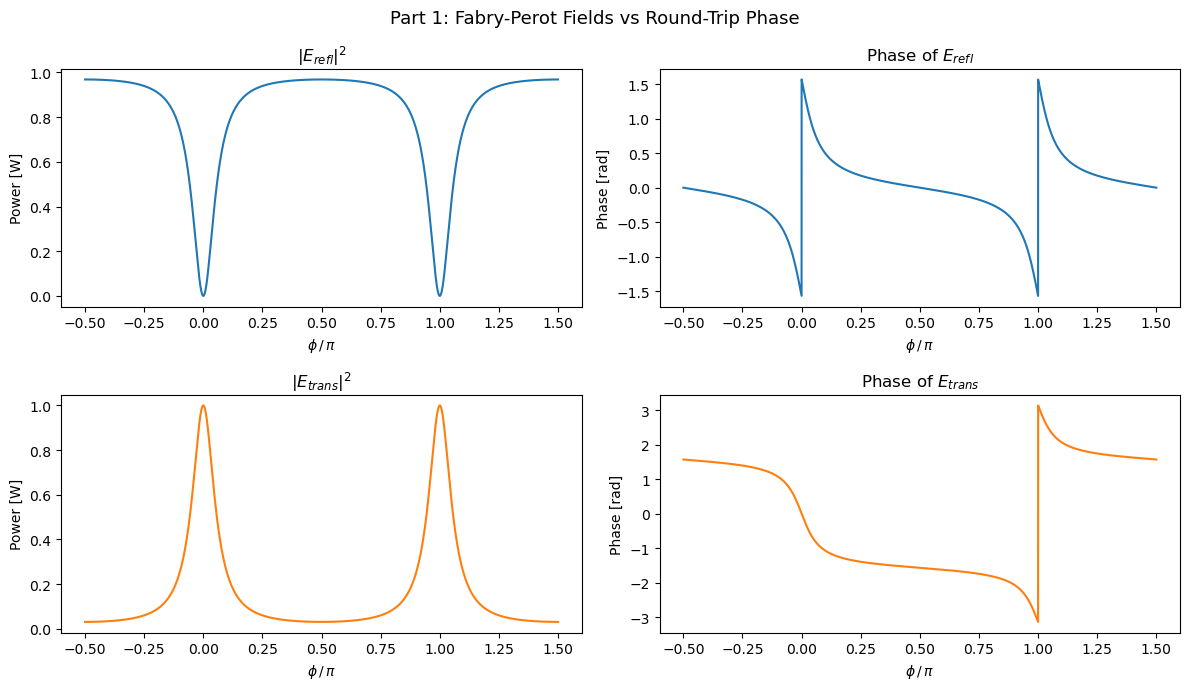

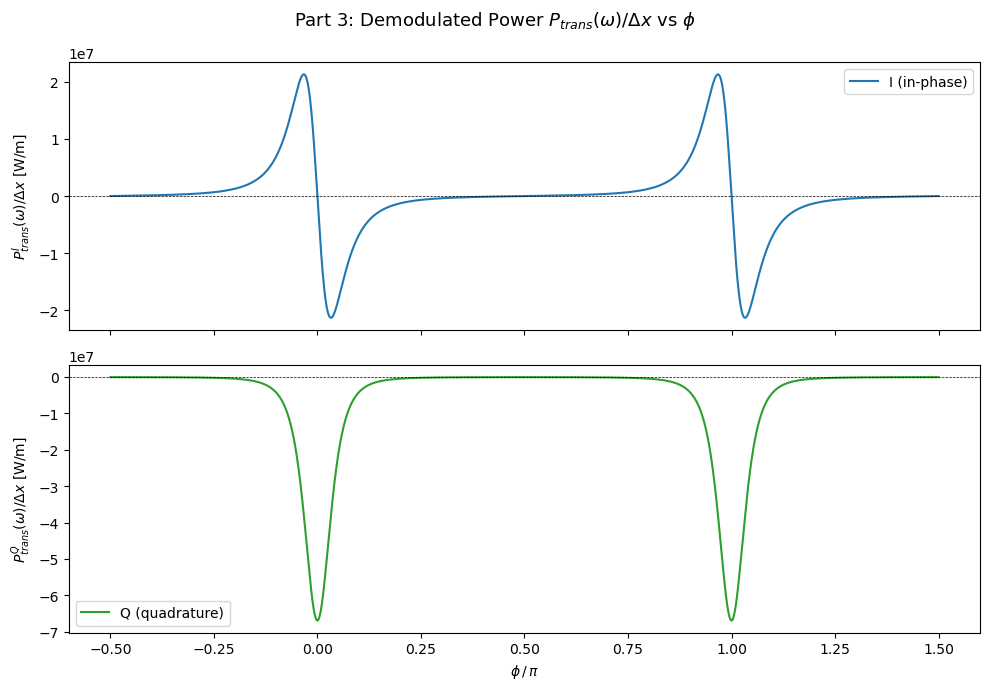

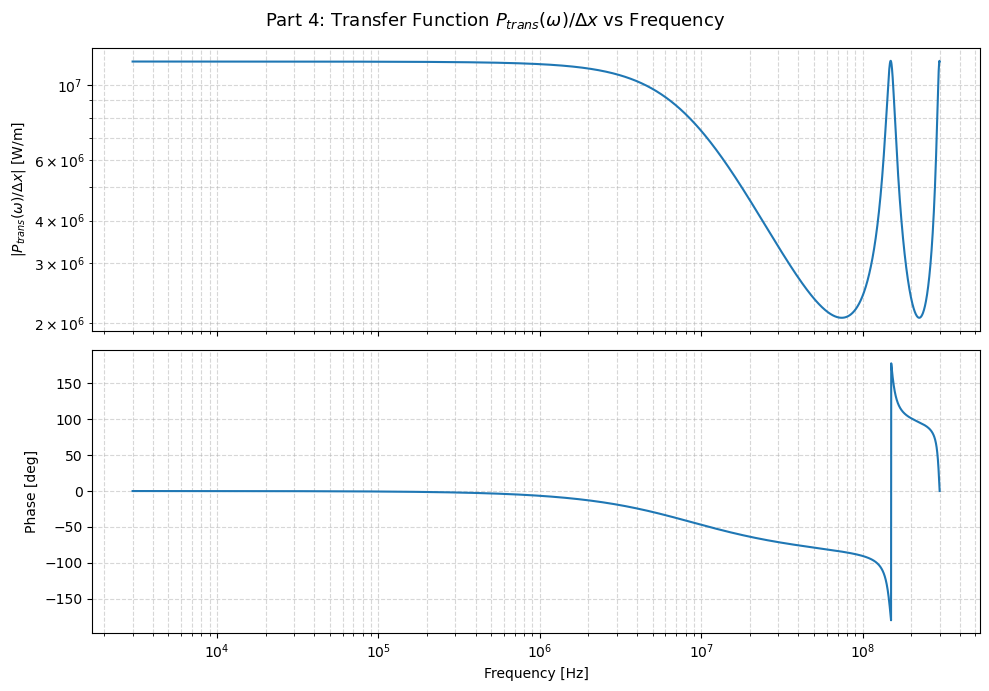

In [20]:
import numpy as np
import matplotlib.pyplot as plt

# ─── Cavity Parameters ───────────────────────────────────────────────────────
L    = 1.0          # cavity length [m]
Pin  = 1.0          # input power [W]
T1   = 0.3          # mirror 1 transmissivity (power)
T2   = 0.3          # mirror 2 transmissivity (power)
lam  = 1064e-9      # wavelength [m]
c    = 3e8          # speed of light [m/s]

# Amplitude coefficients (energy conservation: r^2 + t^2 = 1)
t1 = np.sqrt(T1);  r1 = np.sqrt(1 - T1)
t2 = np.sqrt(T2);  r2 = np.sqrt(1 - T2)

E0 = np.sqrt(Pin)   # input field amplitude

# ─── Part 1: Plot E_refl and E_trans vs phi ──────────────────────────────────
phi = np.linspace(-np.pi/2, 3*np.pi/2, 10000)

denom  = 1 - r1*r2 * np.exp(-2j*phi)
E_refl = E0 * (r1 - r2 * np.exp(-2j*phi)) / denom
E_trans = E0 * (t1*t2 * np.exp(-1j*phi)) / denom

fig, axes = plt.subplots(2, 2, figsize=(12, 7))
fig.suptitle('Part 1: Fabry-Perot Fields vs Round-Trip Phase', fontsize=13)

axes[0, 0].plot(phi/np.pi, np.abs(E_refl)**2)
axes[0, 0].set_title(r'$|E_{refl}|^2$')
axes[0, 0].set_xlabel(r'$\phi\,/\,\pi$')
axes[0, 0].set_ylabel('Power [W]')

axes[0, 1].plot(phi/np.pi, np.angle(E_refl))
axes[0, 1].set_title(r'Phase of $E_{refl}$')
axes[0, 1].set_xlabel(r'$\phi\,/\,\pi$')
axes[0, 1].set_ylabel('Phase [rad]')

axes[1, 0].plot(phi/np.pi, np.abs(E_trans)**2, color='C1')
axes[1, 0].set_title(r'$|E_{trans}|^2$')
axes[1, 0].set_xlabel(r'$\phi\,/\,\pi$')
axes[1, 0].set_ylabel('Power [W]')

axes[1, 1].plot(phi/np.pi, np.angle(E_trans), color='C1')
axes[1, 1].set_title(r'Phase of $E_{trans}$')
axes[1, 1].set_xlabel(r'$\phi\,/\,\pi$')
axes[1, 1].set_ylabel('Phase [rad]')

plt.tight_layout()
plt.savefig('part1_fields.png', dpi=150)
plt.show()

# ─── Part 2: Dither modulation & demodulated power ───────────────────────────
#
# End-mirror modulation: x -> x + Δx·cos(ωt)
# This shifts the round-trip phase:  Φ -> Φ + δφ·cos(ωt)
# where δφ = 2·(2π/λ)·Δx = 4π·Δx/λ   (per unit Δx → set Δx=1 below)
#
# Expand E_trans to first order in δφ (i.e. in Δx):
#   E_trans(t) ≈ E0(φ) + E1(φ)·cos(ωt)
# where E1 = dE_trans/dφ · δφ,  and δφ/Δx = 4π/λ
#
# Power to first order (dropping Δx² terms):
#   P_trans(t) = |E0|² + 2·Re[E0* · E1]·cos(ωt)
#
# Demodulated at ω (complex demodulation):
#   P_trans(ω)/Δx = (E0* · dE_trans/dφ + E0 · dE_trans*/dφ) · (4π/λ)
#                  = 2·Re[E0* · dE_trans/dφ] · (4π/λ)
#
# We compute dE_trans/dφ analytically:

def E_trans_func(phi, E0, t1, t2, r1, r2):
    denom = 1 - r1*r2 * np.exp(-2j*phi)
    return E0 * t1*t2 * np.exp(-1j*phi) / denom

def dE_trans_dphi(phi, E0, t1, t2, r1, r2):
    """Analytic derivative of E_trans with respect to phi."""
    exp2 = np.exp(-2j*phi)
    exp1 = np.exp(-1j*phi)
    denom = 1 - r1*r2*exp2
    # d/dφ [exp(-iφ)/denom] using quotient rule
    num_deriv = (-1j*exp1*denom - exp1*(-r1*r2*(-2j)*exp2)) / denom**2
    return E0 * t1*t2 * num_deriv

# ─── Part 3: Plot Re and Im of P_trans(ω)/Δx vs phi ─────────────────────────
#   P_trans(ω)/Δx = (E0* · dE/dφ + conj) · (4π/λ)
#                 = 2·Re[E0* · dE/dφ] · (4π/λ)   <- real, but we keep complex
#   Full complex demodulation: P_trans_complex(ω)/Δx = E0* · dE/dφ · (4π/λ)

phi = np.linspace(-np.pi/2, 3*np.pi/2, 10000)
omega_mod = 2*np.pi*100  # modulation frequency [rad/s] (from problem, 100 Hz)

E0_field  = E_trans_func(phi, E0, t1, t2, r1, r2)
dE_dphi   = dE_trans_dphi(phi, E0, t1, t2, r1, r2)

dphi_dDx  = 4*np.pi / lam           # δφ per unit Δx  [rad/m]

# Complex demodulated signal (I + iQ)
P_demod = np.conj(E0_field) * dE_dphi * dphi_dDx   # [W/m]

fig, axes = plt.subplots(2, 1, figsize=(10, 7), sharex=True)
fig.suptitle(r'Part 3: Demodulated Power $P_{trans}(\omega)/\Delta x$ vs $\phi$', fontsize=13)

axes[0].plot(phi/np.pi, np.real(P_demod), label='I (in-phase)')
axes[0].axhline(0, color='k', lw=0.5, ls='--')
axes[0].set_ylabel(r'$P^I_{trans}(\omega)/\Delta x$ [W/m]')
axes[0].legend()

axes[1].plot(phi/np.pi, np.imag(P_demod), color='C2', label='Q (quadrature)')
axes[1].axhline(0, color='k', lw=0.5, ls='--')
axes[1].set_ylabel(r'$P^Q_{trans}(\omega)/\Delta x$ [W/m]')
axes[1].set_xlabel(r'$\phi\,/\,\pi$')
axes[1].legend()

plt.tight_layout()
plt.savefig('part3_demodulated.png', dpi=150)
plt.show()

# ─── Part 4: Transfer function magnitude & phase vs frequency ─────────────────
#
# The round-trip phase picks up a frequency-dependent factor because the
# sideband at ω_mod takes time τ = 2L/c to traverse the cavity:
#   Φ(ω) = (ω_carrier + ω_mod)·τ/2  →  extra phase on sideband = ω_mod·τ
#
# Full transfer function including cavity pole:
#   H(f) = E0*(φ)·[dE_trans/dφ evaluated with sideband phase ω_mod·2L/c] · (4π/λ)
#
# More precisely, the sideband field at frequency ω_s = ω_carrier + ω_mod
# accumulates round-trip phase Φ_s = Φ + ω_mod·(2L/c), so:
#   E_trans_sideband(ω_mod) = E_trans_func evaluated at φ + ω_mod·L/c
#   (one-way: φ_s = φ + ω_mod·L/c, round-trip: 2φ_s)

phi0_deg = 1.0
phi0     = phi0_deg * np.pi / 180

f_arr    = np.logspace(np.log10(3e3), np.log10(3e8), 5000)   # 3 kHz – 300 MHz
omega_arr = 2*np.pi * f_arr

# Sideband phase offset per trip: ω_mod * L/c  (one-way travel time)
dphi_sb  = omega_arr * L / c   # [rad]

# Carrier field at phi0
E_carrier = E_trans_func(phi0, E0, t1, t2, r1, r2)

# Sideband field: E_trans evaluated at φ0 + sideband phase offset
E_sb = E_trans_func(phi0 + dphi_sb, E0, t1, t2, r1, r2)

# Transfer function H(f) = E_carrier* · E_sb · (4π/λ)
H = np.conj(E_carrier) * E_sb * dphi_dDx   # [W/m]

fig, axes = plt.subplots(2, 1, figsize=(10, 7), sharex=True)
fig.suptitle(r'Part 4: Transfer Function $P_{trans}(\omega)/\Delta x$ vs Frequency', fontsize=13)

axes[0].loglog(f_arr, np.abs(H))
axes[0].set_ylabel(r'$|P_{trans}(\omega)/\Delta x|$ [W/m]')
axes[0].grid(True, which='both', ls='--', alpha=0.5)

axes[1].semilogx(f_arr, np.degrees(np.angle(H)))
axes[1].set_ylabel(r'Phase [deg]')
axes[1].set_xlabel('Frequency [Hz]')
axes[1].grid(True, which='both', ls='--', alpha=0.5)

plt.tight_layout()
plt.savefig('part4_transfer_function.png', dpi=150)
plt.show()

# Pound-Drever-Hall Michelson

In-class we went over the Pound-Drever-Hall (PDH) Fabry-Perot interferometer.

Now we'll try to apply the same technique lock a Michelson interferometer to it's carrier dark fringe.

Below is a diagram of a Michelson with carrier at $\omega_0$, 
and two RF phase sidebands created by an electro-optic modulator (EOM)
oscillating at $\Omega$ to create two frequencies $\omega_0 \pm \Omega$.\
Our goal is to calculate the PDH error signal $\epsilon_\mathrm{PDH}$ as a function of the carrier phase offset $\phi_d$ and RF sideband frequency $\Omega$.

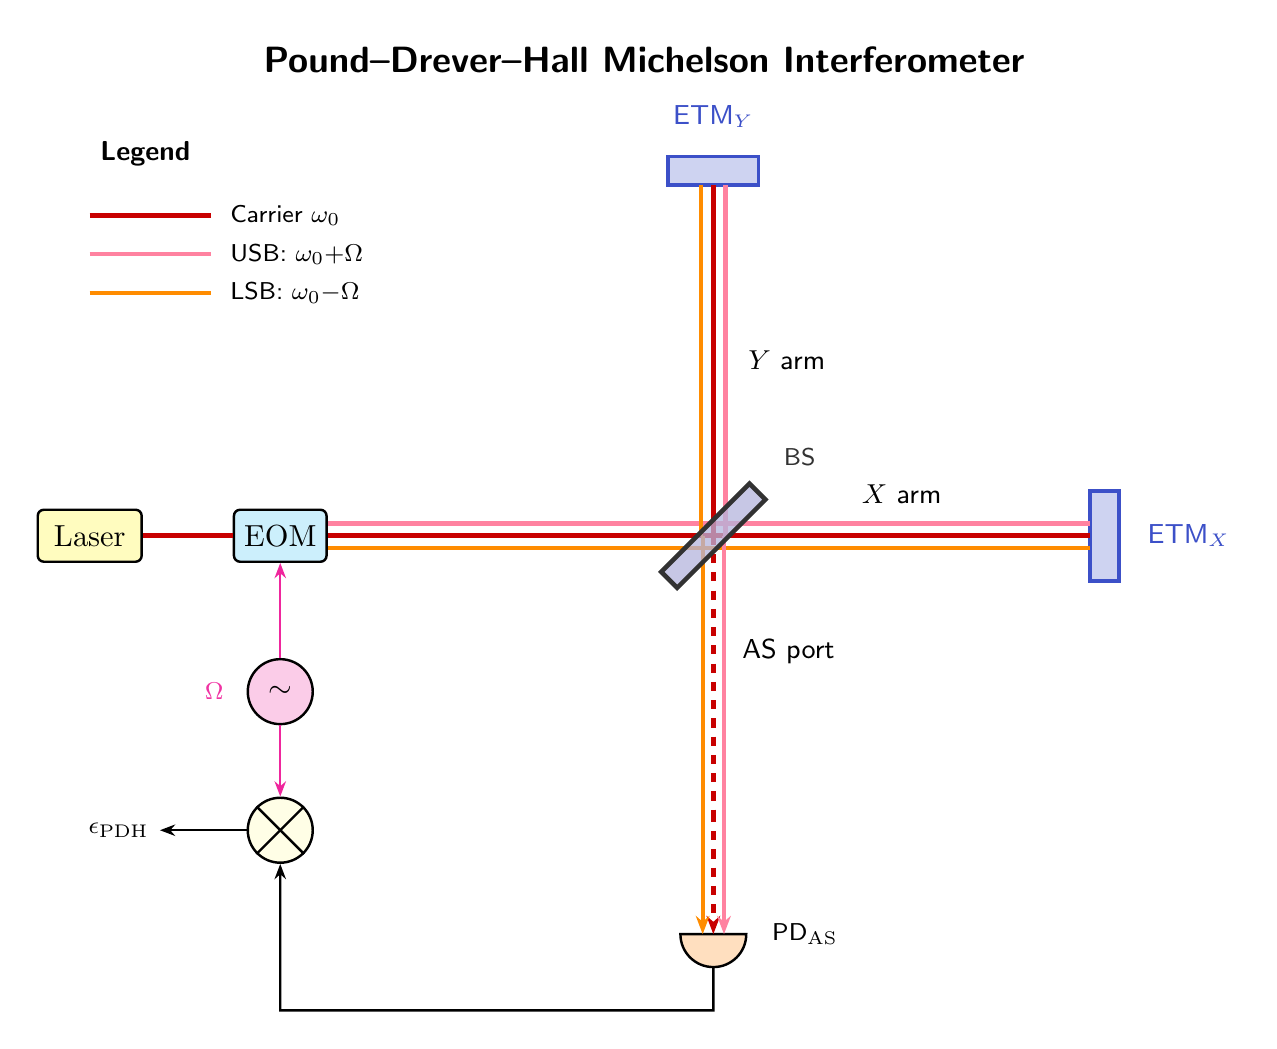

## Calculate the total dark field $E_{as}(t)$.

Calculate the full field expression $E_{as}(t)$ at the dark port of the interferometer.

There should be three contributions, one from carrier and two from the RF phase sidebands injected alongside the carrier.

Let the modulation depth of the RF sideband be $\Gamma$.\
Let the carrier differential phase be $\phi_d = \omega_0 (L_x - L_y) / c$,\
and the RF phase differential phase be $\varphi_d = \Omega (L_x - L_y) / c$.\

What happens to our phases and $E_{as}(t)$ if $L_x = L_y$ exactly?

*Hint: The RF sidebands will experience a phase shift of $\phi_d \pm \varphi_d$ as it transmitted through the interferometer*

## Calculate the total dark power $P_{as}(t)$.

Calculate $P_{as}(t) = |E_{as}(t)|^2$.

Assume that the second order modulation terms $\Gamma^2 = 0$, for simplicity.

## Calculate the dark power demodulated at $\Omega$ 

Calculate and plot the phase sweep of $\dfrac{P_{as}}{\Gamma}(\phi_d, \varphi_d)$ for $\phi_d \in [-5\pi, 5\pi]$.
for some assumed cavity parameters:

$$L_x = 5~\mathrm{m}\\
L_y = 5~\mathrm{m}\\
\Omega = 2 \pi (10~\mathrm{MHz})\\
r_\mathrm{bs} = t_\mathrm{bs} = \dfrac{1}{\sqrt{2}}\\
r_x = r_y = 1
$$

What do you notice about this signal $\dfrac{P_{as}}{\Gamma}(\phi_d, \varphi_d)$ as we increase the offset $\phi_d$?


# <span style="color:rgb(255, 0, 200)">Question 2 Answers</a>

## <span style="color:rgb(253, 120, 255)">2.1: Calculate the total dark field Eas(t)

In class we found 
$$
\frac{E_{\text{as}}}{E_{\text{in}}} = -ie^{-i\Phi_c}\sin{\Phi_d} 
$$

and we know

$$ 
E_{as}(t) = E_{\text{carrier}} + E_{\text{upper sideband}} + E_{\text{lower sideband}} 
$$

then the total field is given by 

$$
E_{as}(t) = E_{in}(-ie^{-i\Phi_c})[J_0(\Gamma)\sin{(\Phi_d)}e^{i\omega_0t}+iJ_1(\Gamma)\sin{(\Phi_d + \varphi_d)}e^{i(\omega_0+\Omega)t} - iJ_{-1}(\Gamma)\sin{(\Phi_d - \varphi_d)}e^{i(\omega_0-\Omega)t} ]
$$

with 
$$
\Phi_d = \omega_0 \frac{L_x - L_y}{c} , \varphi_d = \Omega \frac{L_x - L_y}{c}
$$

##### <span style="color:rgb(207, 139, 208)">What happens to our phases and E_as if the arm lengths are the same?

Without a difference in arm length, both phases go to 0. Thus, there will be no leakage of the RF sidebands into the arms of the interferometer which is necessary for PDH locking. This is why LIGO uses a Schnipp asymmetry of 8cm.


## <span style="color:rgb(253, 120, 255)">2.2: Calculate the total dark power Pas(t)

To simplify E_as we can use 
$$
J_0(\Gamma) = 1\text{ , } J_1(\Gamma)=-J_{-1}(\Gamma)=\frac{\Gamma}{2}
$$
then
$$
E_{as}(t) = E_{in}(-ie^{-i\Phi_c})[\sin{(\Phi_d)}e^{i\omega_0t}+i\frac{\Gamma}{2}\sin{(\Phi_d + \varphi_d)}e^{i(\omega_0+\Omega)t} - i\frac{\Gamma}{2}\sin{(\Phi_d - \varphi_d)}e^{i(\omega_0-\Omega)t} ]
$$
Now, 
$$
P_{as}(t) = |E_{as}(t)|^2 = E_{in}^2 [\sin{(\Phi_d)}-\Gamma \sin{(\Phi_d + \varphi_d)}\sin{(\Omega t)}]
$$
after dropping higher order terms. 



## <span style="color:rgb(253, 120, 255)">2.3: Calculate the dark power demodulated at Omega




In [ ]:
### Mathematica code used for 2.2 and 2.3 ###


# 2.2
'''
$Assumptions = {Ein \[Element] Reals, G \[Element] Reals, Phid \[Element] Reals, phid \[Element] Reals, Phic \[Element] Reals, Om \[Element] Reals, w0 \[Element] Reals, t \[Element] Reals};

Eas = Ein*Exp[I*w0*t]*(-I*Exp[-I*Phic])*(Sin[Phid] + I*(G/2)*Sin[Phid + phid]*Exp[I*Om*t] + I*(G/2)*Sin[Phid - phid]*Exp[-I*Om*t]);

Pas = ComplexExpand[Eas*Conjugate[Eas]] // FullSimplify;
PasFirstOrder = Normal[Series[Pas, {G, 0, 1}]] // FullSimplify
'''


# 2.3:
'''

'''

# Fabry-Perot Michelson Interferometer (FPMI)

We investigated *compound interferometers* in class when we studied the coupled-cavity.\
Here we combine our Michelson interferometer with Fabry-Perot interferometers forming the arms,
forming the Fabry-Perot Michelson Interferometer (FPMI) in a configuration similar to LIGO.

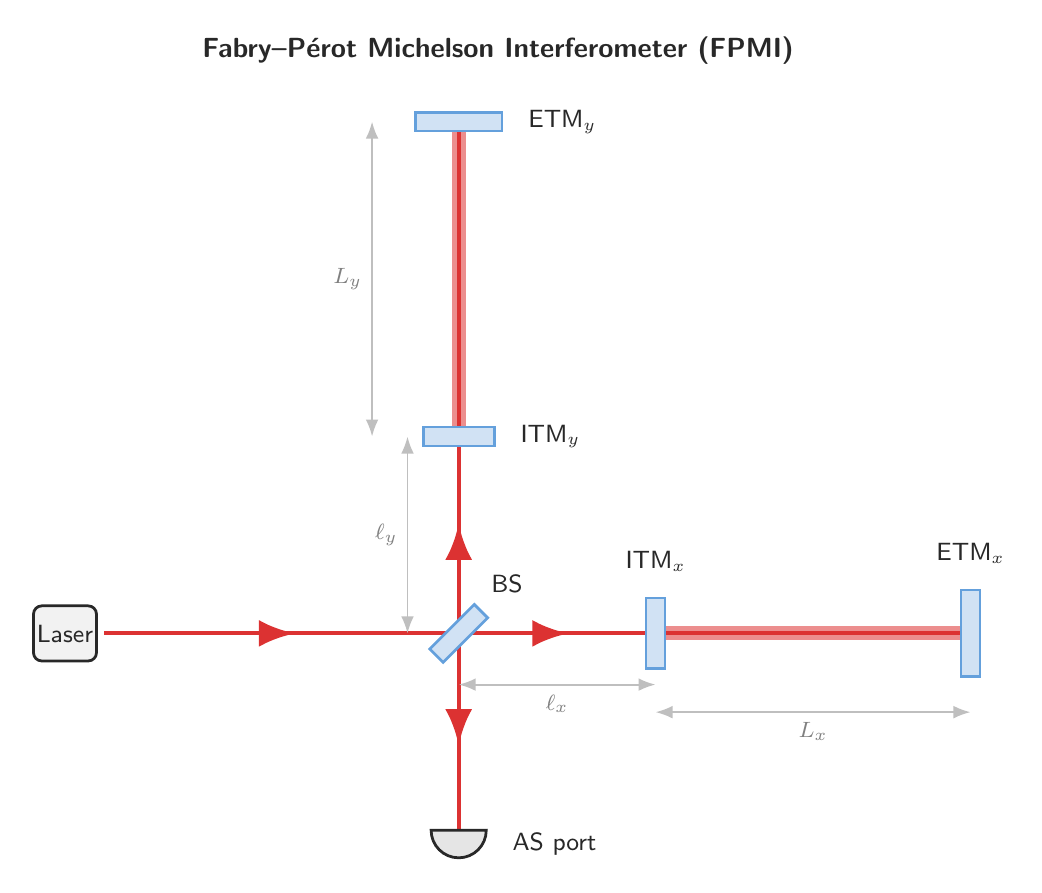

## Adjacency Matrix

Form an adjacency matrix for the FPMI interferometer.

I recommend using $\phi_x = k \ell_x$ and $\phi_y = k \ell_y$ for the short Michelson arms,\
and $\Phi_x = k L_x$ and $\Phi_y = k L_y$ for the Fabry-Perot arm lengths.

## Antisymmetric Port Field Derivations

Find the $\dfrac{E_\mathrm{as}}{E_\mathrm{in}}$ transfer function by inverting the adjacency matrix.

You may also derive the FPMI response by using the compound interferometer technique, 
by letting the common Michelson X-arm reflection $r_x \rightarrow r_\mathrm{FP}(\Phi_x) = \dfrac{E_\mathrm{refl}}{E_\mathrm{in}}$.\
Does this derivation agree with your result from the adjacency matrix?

## Simplifications to $E_\mathrm{as}$

At this point, you may simplify $E_\mathrm{as}$ and change the basis using 
\begin{align}
\Phi_x &= \Phi_c + \Phi_d\\
\Phi_y &= \Phi_c - \Phi_d\\
\phi_x &= 0\\
\phi_y &= 0\\
r_\mathrm{bs} = t_\mathrm{bs} &= \dfrac{1}{\sqrt{2}}\\
r_\mathrm{itmx} &= r_\mathrm{itmy}\\
r_\mathrm{etmx} &= r_\mathrm{etmy}
\end{align}
The above assumes the short Michelson is always perfectly tuned, and the beamsplitter is ideal, and the Fabry-Perot arms are ideally balanced.

## Interpretation

Plot the real and imaginary parts of $\dfrac{E_\mathrm{as}}{E_\mathrm{in}}$ as a function of $\Phi_d$.

Compare to the normal Michelson solution for the AS port.\
Do the Fabry-Perot arms enhance our sensitivity to differential displacement $\Phi_d$?

You may substitute in a moderate finesse Fabry-Perot cavity values
\begin{align}
\ell_x = \ell_y &= 5~\mathrm{m}\\
L_x = L_y &= 4000~\mathrm{m}\\
T_\mathrm{etmx} = T_\mathrm{etmy} &= 0\\
T_\mathrm{itmx} = T_\mathrm{itmy} &= 10\% \\
\end{align}




# <span style="color:rgb(255, 0, 200)">Question 3 Answers</a>

## <span style="color:rgb(253, 120, 255)">3.1: Adjacency Matrix

***Please see my mathematica notebook titled "HW4_notebook" for details on these next few answers.

$$M = \left(\begin{array}{c|ccccccccccc}
 & E_{in} & E_{x1} & E_{xcav} & E_{xcav2} & E_{xrefl} & E_{y1} & E_{ycav} & E_{ycav2} & E_{yrefl} & E_{as} & E_{refl} \\\hline
E_{in}    & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 \\
E_{x1}    & t_{bs}e^{i\phi_x} & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 \\
E_{xcav}  & 0 & t_{xin} & 0 & -r_{xin}e^{i\Phi_x} & 0 & 0 & 0 & 0 & 0 & 0 & 0 \\
E_{xcav2} & 0 & 0 & -r_{xend}e^{-i\Phi_x} & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 \\
E_{xrefl} & 0 & r_{xin} & 0 & t_{xin} & 0 & 0 & 0 & 0 & 0 & 0 & 0 \\
E_{y1}    & -r_{bs}e^{i\phi_y} & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 \\
E_{ycav}  & 0 & 0 & 0 & 0 & 0 & t_{yin} & 0 & -r_{yin}e^{i\Phi_y} & 0 & 0 & 0 \\
E_{ycav2} & 0 & 0 & 0 & 0 & 0 & 0 & -r_{yend}e^{i\Phi_y} & 0 & 0 & 0 & 0 \\
E_{yrefl} & 0 & 0 & 0 & 0 & 0 & r_{yin} & 0 & t_{yin} & 0 & 0 & 0 \\
E_{as}    & 0 & 0 & 0 & 0 & r_{bs}e^{i\phi_x} & 0 & 0 & 0 & t_{bs}e^{i\phi_y} & 0 & 0 \\
E_{refl}  & 0 & 0 & 0 & 0 & t_{bs}e^{i\phi_x} & 0 & 0 & 0 & -r_{bs}e^{i\phi_y} & 0 & 0 \\
\end{array}\right)$$


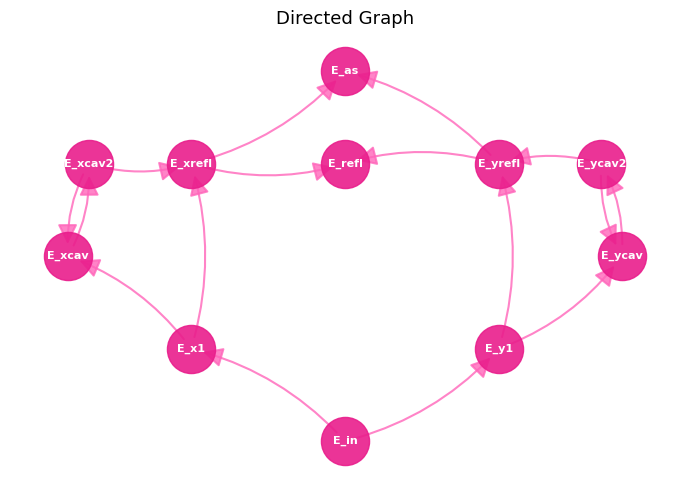

In [63]:
### Shoutout Claude for helping translate my mathematica code for this diagram into python code ###

import networkx as nx
import matplotlib.pyplot as plt

nodes = ["E_in", "E_x1", "E_xcav", "E_xcav2", "E_xrefl",
         "E_y1", "E_ycav", "E_ycav2", "E_yrefl", "E_as", "E_refl"]

edges = [
    ("E_in",    "E_x1"),
    ("E_in",    "E_y1"),
    ("E_x1",    "E_xcav"),
    ("E_x1",    "E_xrefl"),
    ("E_xcav",  "E_xcav2"),
    ("E_xcav2", "E_xcav"),
    ("E_xcav2", "E_xrefl"),
    ("E_y1",    "E_ycav"),
    ("E_y1",    "E_yrefl"),
    ("E_ycav",  "E_ycav2"),
    ("E_ycav2", "E_ycav"),
    ("E_ycav2", "E_yrefl"),
    ("E_xrefl", "E_as"),
    ("E_yrefl", "E_as"),
    ("E_xrefl", "E_refl"),
    ("E_yrefl", "E_refl"),
]

G = nx.DiGraph()
G.add_nodes_from(nodes)
G.add_edges_from(edges)

pos = {
    "E_in":    ( 0.0, -2.0),
    "E_x1":   (-1.5, -1.0),
    "E_xcav": (-2.7,  0.0),
    "E_xcav2":(-2.5,  1.0),
    "E_xrefl":(-1.5,  1.0),
    "E_y1":   ( 1.5, -1.0),
    "E_ycav": ( 2.7,  0.0),
    "E_ycav2":( 2.5,  1.0),
    "E_yrefl":( 1.5,  1.0),
    "E_as":   ( 0.0,  2.0),
    "E_refl": ( 0.0,  1.0),
}

fig, ax = plt.subplots(figsize=(7, 5))

nx.draw_networkx_nodes(G, pos, ax=ax,
    node_color="#e91e8c", node_size=1200, alpha=0.9)

nx.draw_networkx_labels(G, pos, ax=ax,
    font_size=8, font_color="white", font_weight="bold")

nx.draw_networkx_edges(G, pos, ax=ax,
    edge_color="#ff65ba", arrows=True,
    arrowstyle="-|>", arrowsize=30,
    connectionstyle="arc3,rad=0.15",
    width=1.5, alpha=0.8)

ax.set_title("Directed Graph", fontsize=13)
ax.axis("off")
plt.tight_layout()
plt.show()


## <span style="color:rgb(253, 120, 255)">3.2: Asymmetric port field derivations

$$\frac{E_{as}}{E_{in}} = \frac{r_{bs}\, t_{bs}\Big(e^{2i\phi_x}r_{xin} - e^{2i(\phi_x+\Phi_x)}r_{xend}r_{xin}^2 - e^{2i\phi_y}r_{yin} + e^{2i(\Phi_x+\phi_y)}r_{xend}r_{xin}r_{yin} - e^{2i(\phi_x+\Phi_y)}r_{xin}r_{yend}r_{yin} + e^{2i(\phi_x+\Phi_x+\Phi_y)}r_{xend}r_{xin}^2 r_{yend}r_{yin} + e^{2i(\phi_y+\Phi_y)}r_{yend}r_{yin}^2 - e^{2i(\Phi_x+\phi_y+\Phi_y)}r_{xend}r_{xin}r_{yend}r_{yin}^2 - e^{i(2\phi_x+\Phi_x)}r_{xend}t_{xin}^2 + e^{i(2\phi_x+\Phi_x+2\Phi_y)}r_{xend}r_{yend}r_{yin}t_{xin}^2 + e^{i(2\phi_y+\Phi_y)}r_{yend}t_{yin}^2 - e^{i(2(\Phi_x+\phi_y)+\Phi_y)}r_{xend}r_{xin}r_{yend}t_{yin}^2\Big)}{(-1+e^{2i\Phi_x}r_{xend}r_{xin})(-1+e^{2i\Phi_y}r_{yend}r_{yin})}$$

Yikes


## <span style="color:rgb(253, 120, 255)">3.3: Simplifications to Eas

After the following simplifications:

$$
\Phi_x = \Phi_c + \Phi_d \\
\Phi_y = \Phi_c - \Phi_d \\
\phi_x = 0 \\
\phi_x = 0 \\
r_{bs} = t_{bs} = \frac{1}{\sqrt{2}} \\
r_{Xend} = r_{Yend} \\
r_{Xin} = r_{Yin}
$$

we get

$$\frac{E_{as}}{E_{in}} = \frac{e^{i(\Phi_c+\Phi_d)}(-1+e^{2i\Phi_d})\,r_2(1+e^{2i\Phi_c}r_1 r_2)\,t_1^2}{2(e^{2i\Phi_d}-e^{2i\Phi_c}r_1 r_2)(-1+e^{2i(\Phi_c+\Phi_d)}r_1 r_2)}$$


## <span style="color:rgb(253, 120, 255)">3.4: Interpretation

The demonstrated by the much steeper slope of the FPMI vs the normal MI below, the Fabry-Perot arms do indeed improve our differential displacement sensitivity as expected. 



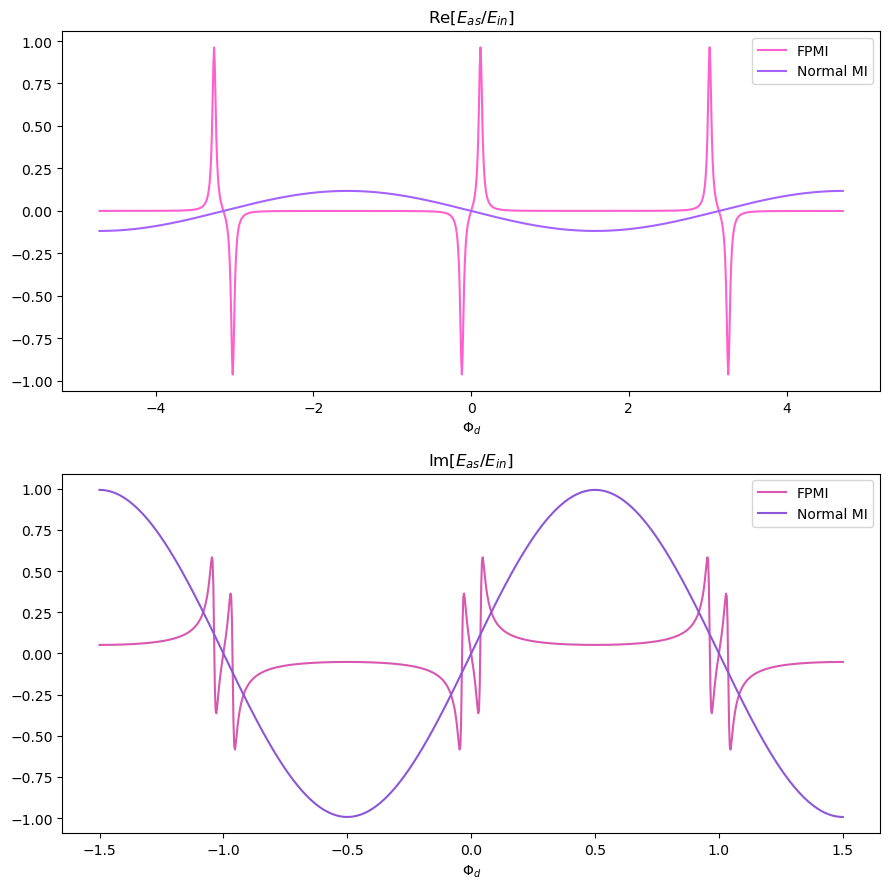

In [53]:
import numpy as np
import matplotlib.pyplot as plt

r1, r2 = np.sqrt(1 - 0.10), 1
t1 = np.sqrt(0.10)
k = (2*np.pi) / (1064e-9)  
lx, ly = 5, 5
Lx, Ly = 4000, 4000
Phic = k * (Lx + Ly)     # Phic = Phix+Phiy from class
Phid = np.linspace(-3*np.pi/2, 3*np.pi/2, 1000)

E_as = np.exp(1j*(Phic+Phid)) * (-1+np.exp(2j*Phid)) * r2 * (1+np.exp(2j*Phic)*r1*r2) * t1**2
E_in = 2 * (np.exp(2j*Phid) - np.exp(2j*Phic)*r1*r2) * (-1+np.exp(2j*(Phic+Phid))*r1*r2)
E_tf = E_as / E_in
E_mich = -1j*np.exp(-1j*Phic)*np.sin(Phid)  #normal michaelson, found this expression in class

fig, ax = plt.subplots(2, 1, figsize=(9, 9))

ax[0].plot(Phid, np.real(E_tf),  color="#ff60cf", label = "FPMI")
ax[0].plot(Phid, np.real(E_mich), color="#a463ff", label="Normal MI")
ax[0].set_title(r'Re[$E_{as}/E_{in}$]')
ax[0].set_xlabel(r'$\Phi_d$')
ax[0].legend(loc="upper right")

ax[1].plot(Phid/np.pi, np.imag(E_tf), color="#d757b1", label = "FPMI")
ax[1].plot(Phid/np.pi, np.imag(E_mich), color="#8c57d7", label="Normal MI")
ax[1].set_title(r'Im[$E_{as}/E_{in}$]')
ax[1].set_xlabel(r'$\Phi_d$')
ax[1].legend(loc="upper right")

plt.tight_layout()
plt.show()